# Segmentación avanzada de clientes de tarjeta de crédito

## KPIs · Transformaciones robustas · Estabilidad · UMAP/HDBSCAN

Este notebook continúa el
[`workshop-clustering-creditcard.ipynb`](workshop-clustering-creditcard.ipynb) sin
modificar su alcance introductorio. Es autocontenido: vuelve a cargar y preparar los
datos para que pueda ejecutarse de principio a fin de forma independiente.

## Objetivos

- Construir KPIs que aporten contexto a los importes absolutos.
- Medir el efecto de `log1p` sobre variables muy sesgadas.
- Comparar la nueva partición con el K-Means base.
- Evaluar estabilidad mediante submuestreo.
- Explicar por qué no puede realizarse una validación temporal real.
- Explorar estructura no lineal mediante UMAP y HDBSCAN.

In [1]:
# Configuración e imports
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap

from sklearn.cluster import HDBSCAN, KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    davies_bouldin_score,
    silhouette_score,
)
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.3f}".format)
sns.set_theme(context="notebook", style="whitegrid", palette="muted")
plt.rcParams.update({"figure.figsize": (10, 6), "figure.dpi": 120})

print("Entorno avanzado configurado.")
print(f"UMAP {umap.__version__}")

Entorno avanzado configurado.
UMAP 0.5.12


## 1. Carga y preparación reproducible

Se elimina `CUST_ID`, se imputan los dos campos con nulos mediante la mediana y se
estandarizan las 17 variables originales. El modelo base usa `k=3`, seleccionado en el
workshop introductorio.

In [2]:
raw_df = pd.read_csv("data/credit_card.csv")
df = raw_df.drop(columns="CUST_ID").copy()
df = df.fillna(df.median(numeric_only=True))

assert df.isna().sum().sum() == 0
assert df.shape[1] == 17

BEST_K = 3
scaler_base = StandardScaler()
X_base = scaler_base.fit_transform(df)
base_model = KMeans(
    n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20
)
labels_base = base_model.fit_predict(X_base)

rng = np.random.default_rng(RANDOM_STATE)
eval_idx = rng.choice(len(df), size=min(3000, len(df)), replace=False)

print(f"Clientes: {len(df):,}")
print(f"Variables base: {df.shape[1]}")
print(f"Silhouette base: {silhouette_score(X_base[eval_idx], labels_base[eval_idx]):.3f}")

Clientes: 8,950
Variables base: 17
Silhouette base: 0.251


## 2. Ingeniería de KPIs

Se crean cuatro ratios mediante división segura:

- utilización del crédito: `BALANCE / CREDIT_LIMIT`;
- compra media por transacción;
- adelanto medio por transacción;
- pagos respecto al mínimo requerido.

Cuando el denominador es cero, el ratio se fija en cero para evitar infinitos.

In [3]:
def safe_ratio(numerator, denominator):
    return np.divide(
        numerator,
        denominator,
        out=np.zeros_like(numerator, dtype=float),
        where=np.asarray(denominator) > 0,
    )

df_kpi = df.copy()
df_kpi["CREDIT_UTILIZATION"] = safe_ratio(
    df["BALANCE"].to_numpy(), df["CREDIT_LIMIT"].to_numpy()
)
df_kpi["AVG_PURCHASE_PER_TRX"] = safe_ratio(
    df["PURCHASES"].to_numpy(), df["PURCHASES_TRX"].to_numpy()
)
df_kpi["AVG_CASH_ADVANCE_PER_TRX"] = safe_ratio(
    df["CASH_ADVANCE"].to_numpy(), df["CASH_ADVANCE_TRX"].to_numpy()
)
df_kpi["PAYMENT_TO_MINIMUM_RATIO"] = safe_ratio(
    df["PAYMENTS"].to_numpy(), df["MINIMUM_PAYMENTS"].to_numpy()
)

kpi_cols = [
    "CREDIT_UTILIZATION",
    "AVG_PURCHASE_PER_TRX",
    "AVG_CASH_ADVANCE_PER_TRX",
    "PAYMENT_TO_MINIMUM_RATIO",
]
assert np.isfinite(df_kpi[kpi_cols].to_numpy()).all()
display(df_kpi[kpi_cols].describe(percentiles=[0.5, 0.9, 0.99]).T.round(3))

,count,mean,std,min,50%,90%,99%,max
CREDIT_UTILIZATION,"8,950.000",0.389,0.390,0.000,0.303,0.920,1.057,15.910
AVG_PURCHASE_PER_TRX,"8,950.000",73.871,160.525,0.000,41.394,147.555,756.992,"5,981.667"
AVG_CASH_ADVANCE_PER_TRX,"8,950.000",208.905,535.656,0.000,0.000,561.067,"1,909.183","14,836.451"
PAYMENT_TO_MINIMUM_RATIO,"8,950.000",9.059,118.181,0.000,2.033,13.071,49.712,"6,840.529"


## 3. Efecto de KPIs y `log1p`

Comparamos tres representaciones con el mismo algoritmo y `k`. `log1p` se aplica
solamente a importes y ratios no negativos; las frecuencias permanecen en su escala
original antes de estandarizar.

El ARI mide cuánto cambia la asignación respecto al modelo base, ignorando la
permutación de las etiquetas.

In [4]:
# Representación con KPIs, sin transformación logarítmica
X_kpi = StandardScaler().fit_transform(df_kpi)
labels_kpi = KMeans(
    n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20
).fit_predict(X_kpi)

# Representación con KPIs y log1p
log_cols = [
    "BALANCE", "PURCHASES", "ONEOFF_PURCHASES", "INSTALLMENTS_PURCHASES",
    "CASH_ADVANCE", "CREDIT_LIMIT", "PAYMENTS", "MINIMUM_PAYMENTS",
    "CREDIT_UTILIZATION", "AVG_PURCHASE_PER_TRX",
    "AVG_CASH_ADVANCE_PER_TRX", "PAYMENT_TO_MINIMUM_RATIO",
]
df_log_kpi = df_kpi.copy()
df_log_kpi[log_cols] = np.log1p(df_log_kpi[log_cols].clip(lower=0))
scaler_log_kpi = StandardScaler()
X_log_kpi = scaler_log_kpi.fit_transform(df_log_kpi)
enhanced_model = KMeans(
    n_clusters=BEST_K, random_state=RANDOM_STATE, n_init=20
)
labels_enhanced = enhanced_model.fit_predict(X_log_kpi)

rows = []
for name, data, labels in [
    ("Base", X_base, labels_base),
    ("Base + KPIs", X_kpi, labels_kpi),
    ("Base + KPIs + log1p", X_log_kpi, labels_enhanced),
]:
    rows.append({
        "representación": name,
        "silhouette": silhouette_score(data[eval_idx], labels[eval_idx]),
        "davies_bouldin": davies_bouldin_score(data[eval_idx], labels[eval_idx]),
        "ARI_vs_base": adjusted_rand_score(labels_base, labels),
        "segmento_mayor_pct": (
            100 * pd.Series(labels).value_counts(normalize=True).max()
        ),
    })

representation_comparison = pd.DataFrame(rows).set_index("representación")
display(representation_comparison.round(3))

,silhouette,davies_bouldin,ARI_vs_base,segmento_mayor_pct
representación,,,,
Base,0.251,1.585,1.000,68.369
Base + KPIs,0.175,1.796,0.392,54.749
Base + KPIs + log1p,0.210,1.768,0.136,35.374


### Interpretación

Los KPIs y `log1p` no aumentan el *silhouette*: cambian la pregunta analítica. El modelo
base favorece grupos compactos dominados por importes absolutos; la versión ampliada
equilibra mucho más los tamaños y da mayor peso a patrones relativos de utilización y
pago. La selección final depende de la utilidad de negocio, no solo de una métrica.

,segmento,clientes,BALANCE,PURCHASES,CASH_ADVANCE,CREDIT_UTILIZATION,AVG_PURCHASE_PER_TRX,AVG_CASH_ADVANCE_PER_TRX,PAYMENT_TO_MINIMUM_RATIO
cluster,,,,,,,,,
0,Adelantos y alta utilización,2886,"2,371.490",89.900,"2,167.730",0.610,30.340,455.580,4.040
1,Transaccionales de bajo saldo,2898,164.900,522.630,30.050,0.080,93.430,16.880,17.310
2,Compradores de alto valor,3166,"2,109.930","2,275.640",763.660,0.470,95.650,159.820,6.080


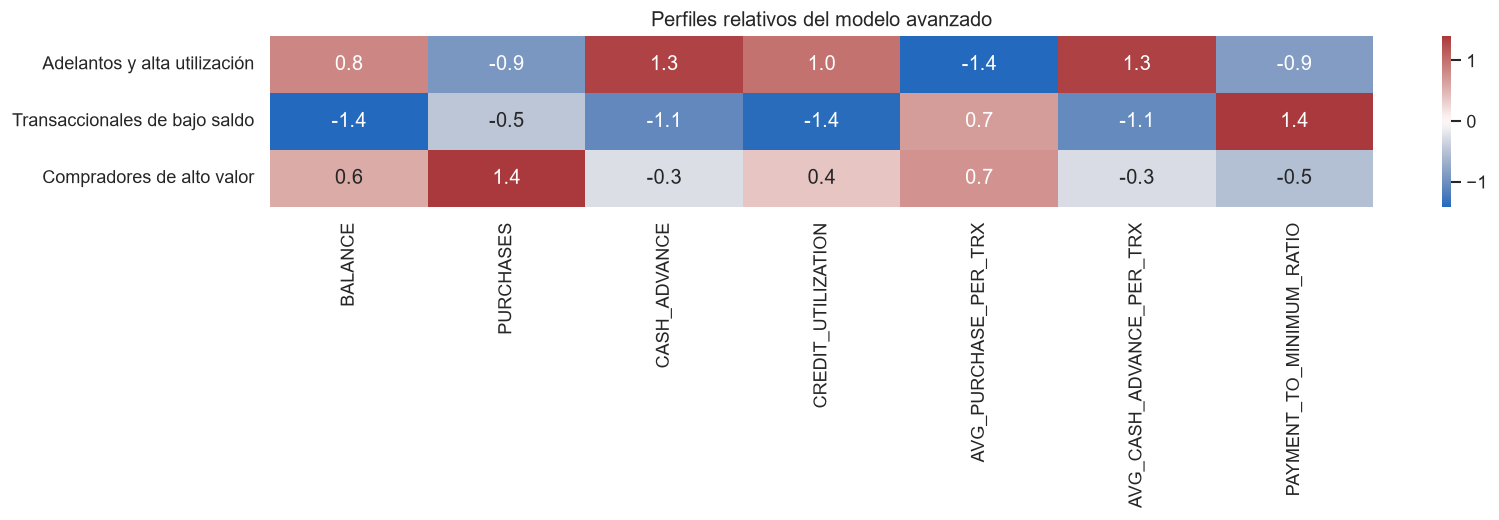

In [5]:
# Perfiles avanzados en unidades originales
profiles = df_kpi.assign(cluster=labels_enhanced).groupby("cluster").mean()

cash_cluster = int(profiles["CASH_ADVANCE"].idxmax())
purchase_cluster = int(profiles["PURCHASES"].idxmax())
remaining_cluster = int(
    next(c for c in profiles.index if c not in {cash_cluster, purchase_cluster})
)
segment_names = {
    cash_cluster: "Adelantos y alta utilización",
    purchase_cluster: "Compradores de alto valor",
    remaining_cluster: "Transaccionales de bajo saldo",
}

profile_cols = [
    "BALANCE", "PURCHASES", "CASH_ADVANCE", "CREDIT_UTILIZATION",
    "AVG_PURCHASE_PER_TRX", "AVG_CASH_ADVANCE_PER_TRX",
    "PAYMENT_TO_MINIMUM_RATIO",
]
profile_table = profiles[profile_cols].copy()
profile_table.insert(0, "segmento", pd.Series(segment_names))
profile_table.insert(
    1,
    "clientes",
    pd.Series(labels_enhanced).value_counts().sort_index(),
)
display(profile_table.round(2))

profile_z = (
    profiles[profile_cols] - profiles[profile_cols].mean()
) / profiles[profile_cols].std(ddof=0)
plt.figure(figsize=(14, 4.5))
sns.heatmap(profile_z, cmap="vlag", center=0, annot=True, fmt=".1f")
plt.yticks(
    np.arange(len(profile_z)) + 0.5,
    [segment_names[i] for i in profile_z.index],
    rotation=0,
)
plt.title("Perfiles relativos del modelo avanzado")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 4. Estabilidad y límite de la validación temporal

El dataset contiene agregados de seis meses, pero no incluye fecha ni periodo.
`TENURE` indica meses observados, no un instante temporal. Por tanto, no es posible
validar deriva temporal sin inventar información.

Como alternativa, entrenamos diez modelos sobre submuestras del 80 % y predecimos el
conjunto completo. El ARI frente al modelo avanzado de referencia mide sensibilidad al
muestreo. La tabla por `TENURE` es solo un control de cobertura.

In [6]:
stability_rows = []
for seed in range(10):
    sample_idx = np.random.default_rng(seed).choice(
        len(X_log_kpi), size=int(0.80 * len(X_log_kpi)), replace=False
    )
    sampled_model = KMeans(
        n_clusters=BEST_K, random_state=seed, n_init=20
    ).fit(X_log_kpi[sample_idx])
    sampled_labels = sampled_model.predict(X_log_kpi)
    stability_rows.append({
        "semilla": seed,
        "ARI_vs_referencia": adjusted_rand_score(
            labels_enhanced, sampled_labels
        ),
        "segmento_mayor_pct": (
            100 * pd.Series(sampled_labels).value_counts(normalize=True).max()
        ),
    })

stability_results = pd.DataFrame(stability_rows)
display(stability_results.round(3))
print(
    "ARI medio ± desviación: "
    f"{stability_results['ARI_vs_referencia'].mean():.3f} ± "
    f"{stability_results['ARI_vs_referencia'].std():.3f}"
)

tenure_coverage = pd.crosstab(
    df["TENURE"], labels_enhanced, normalize="index"
).mul(100)
tenure_coverage.columns = [f"cluster_{c}" for c in tenure_coverage.columns]
display(tenure_coverage.round(1).rename_axis("TENURE (meses)"))

,semilla,ARI_vs_referencia,segmento_mayor_pct
0,0,0.976,35.877
1,1,0.945,34.101
2,2,0.976,34.983
3,3,0.965,36.168
4,4,0.975,34.827
5,5,0.631,37.911
6,6,0.950,34.279
7,7,0.965,34.648
8,8,0.976,34.670
9,9,0.968,34.637


ARI medio ± desviación: 0.933 ± 0.107


,cluster_0,cluster_1,cluster_2
TENURE (meses),,,
6,42.600,47.100,10.300
7,46.800,36.300,16.800
8,45.900,37.200,16.800
9,46.300,41.100,12.600
10,41.500,39.800,18.600
11,45.800,29.000,25.200
12,30.000,31.500,38.500


## 5. UMAP + HDBSCAN

UMAP crea una representación no lineal de cinco dimensiones y HDBSCAN busca regiones
densas sin fijar previamente el número de clusters. Las dos primeras dimensiones UMAP
se usan únicamente para el gráfico.

El *silhouette* resultante se calcula en el embedding, por lo que no es directamente
comparable con el del espacio original.

Clusters HDBSCAN: 6
Ruido HDBSCAN   : 0.0%
Silhouette sin ruido (UMAP): 0.727
ARI vs K-Means avanzado     : 0.347


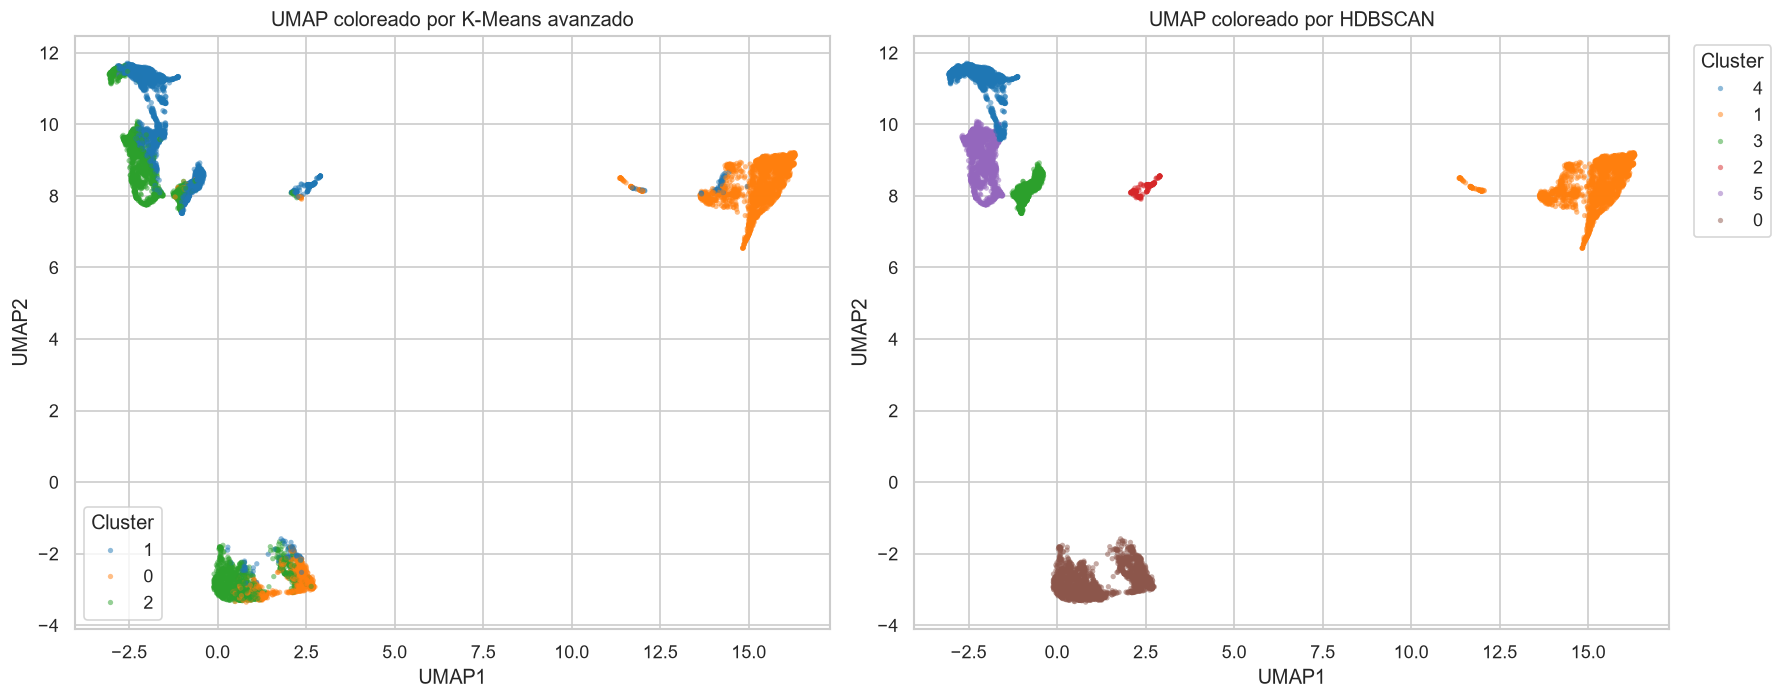

,clientes
cluster,
0,2202
1,2062
4,1825
5,1646
3,1050
2,165


In [7]:
umap_model = umap.UMAP(
    n_neighbors=30,
    min_dist=0.05,
    n_components=5,
    metric="euclidean",
    random_state=RANDOM_STATE,
    n_jobs=1,
)
X_umap = umap_model.fit_transform(X_log_kpi)

hdbscan_model = HDBSCAN(
    min_cluster_size=150,
    min_samples=20,
    cluster_selection_method="eom",
    copy=True,
)
labels_hdbscan = hdbscan_model.fit_predict(X_umap)
non_noise = labels_hdbscan != -1
n_clusters = len(np.unique(labels_hdbscan[non_noise]))
noise_rate = 1 - non_noise.mean()

print(f"Clusters HDBSCAN: {n_clusters}")
print(f"Ruido HDBSCAN   : {noise_rate:.1%}")
if n_clusters >= 2:
    score_hdbscan = silhouette_score(
        X_umap[non_noise],
        labels_hdbscan[non_noise],
        sample_size=min(3000, non_noise.sum()),
        random_state=RANDOM_STATE,
    )
    ari_hdbscan = adjusted_rand_score(
        labels_enhanced[non_noise], labels_hdbscan[non_noise]
    )
    print(f"Silhouette sin ruido (UMAP): {score_hdbscan:.3f}")
    print(f"ARI vs K-Means avanzado     : {ari_hdbscan:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=labels_enhanced.astype(str), palette="tab10",
    s=10, alpha=0.5, linewidth=0, ax=axes[0],
)
axes[0].set_title("UMAP coloreado por K-Means avanzado")
axes[0].legend(title="Cluster")

plot_hdbscan = labels_hdbscan.astype(str)
plot_hdbscan[labels_hdbscan == -1] = "ruido"
sns.scatterplot(
    x=X_umap[:, 0], y=X_umap[:, 1],
    hue=plot_hdbscan, palette="tab10",
    s=10, alpha=0.5, linewidth=0, ax=axes[1],
)
axes[1].set_title("UMAP coloreado por HDBSCAN")
axes[1].legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
for ax in axes:
    ax.set(xlabel="UMAP1", ylabel="UMAP2")
plt.tight_layout()
plt.show()

display(
    pd.Series(plot_hdbscan, name="cluster")
      .value_counts()
      .rename("clientes")
      .to_frame()
)

---
## Conclusiones

- Añadir KPIs cambia materialmente la segmentación: el ARI frente al modelo base baja
  hasta aproximadamente 0.14 al incorporar también `log1p`.
- La representación avanzada reduce el segmento mayoritario del 68.37 % al 35.37 %.
  Su *silhouette* es menor (0.21 frente a 0.25), pero los grupos quedan más
  equilibrados.
- La estabilidad por submuestreo es alta: ARI medio **0.933**, aunque una semilla
  revela una caída que conviene investigar.
- UMAP + HDBSCAN encuentra seis regiones compactas en el embedding, con *silhouette*
  0.727 y ARI 0.347 frente a K-Means avanzado. Es una estructura alternativa, no una
  mejora demostrada del modelo de negocio.
- Una validación temporal real requiere datos separados por fecha o periodo. No puede
  realizarse honestamente con este archivo agregado.

## Recomendación

Mantener K-Means base como referencia sencilla y comparar la versión avanzada mediante
rentabilidad, riesgo y estabilidad en nuevos periodos. UMAP/HDBSCAN debe tratarse como
análisis exploratorio hasta demostrar que sus seis grupos son estables y accionables.